# 🌿 PLANesT-3D — Controlled Degradation Pipeline (GT → Noisy Reconstructions)
### Plant: `Ribes_04`

This notebook takes your **clean ground-truth** point cloud
(`gt_reconstruction/`) and generates a full battery of **controlled,
parametrized degradations** that mimic real reconstruction artifacts
(COLMAP / MASt3R style failure modes), saving each variant into
`noisy_reconstruction/degraded/...` — **without ever touching the GT files**.

Every degradation keeps `XYZ`, `RGB`, `semantic label`, `instance label` and
`confidence` **perfectly aligned per point** — when a point is dropped, its
label/confidence is dropped with it; nothing is decoupled or re-indexed.

**Degradations implemented**
1. **Density reduction** — uniform random subsampling: 100% / 75% / 50% / 25% / 10%
2. **Coordinate noise** — isotropic Gaussian jitter, σ expressed as a **% of the
   plant's characteristic size** (bounding-box diagonal): low (0.1%) / medium (0.5%) / high (1%)
3. **Random missing points** — spatially **clumped** removal (not i.i.d. like #1),
   simulating incomplete reconstruction: 10% / 30% / 50% removed
4. **Missing regions** — spherical cutouts simulating occlusion / self-occlusion
   / reconstruction failure over a whole plant part: small / medium / large
5. **Uneven density** — per-instance (per-leaf/per-organ) variable keep-fraction,
   simulating "leaf A dense, leaf B sparse": mild / moderate / severe
6. **RGB / illumination** — brightness, contrast, and color-shift perturbations
   (only if the GT `.ply` carries color): dark / bright / low_contrast / color_shift

Each stage also renders a **GT-vs-levels comparison figure** (saved as PNG) so
you can drop it straight into your paper's "degradation protocol" section, and
a global `manifest.csv` logs every generated variant with its exact parameters
and resulting point count.

> Runtime: CPU is enough. For very large clouds (millions of points), the
> spatially-clumped removal (#3) and region cutouts (#4) may take a minute or two
> — this is expected (they use KD-tree neighborhood queries, not simple random draws).


## 1. Setup

In [1]:
!pip install -q open3d plyfile scipy pandas numpy matplotlib seaborn tqdm
print("Dependencies ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 140.6 MB/s eta 0:00:00
Dependencies ready.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Configuration — paths (GT input, degraded output)

In [3]:
import os

# --- Dataset location -------------------------------------------------------
BASE_DIR   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
PLANT_NAME = "Ribes_04"

# GT reconstruction folder (READ-ONLY in this notebook — never modified)
GT_DIR = os.path.join(BASE_DIR, "gt_reconstruction")

PLY_PATH        = os.path.join(GT_DIR, f"{PLANT_NAME}.ply")
SEMANTIC_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_SemanticLabels.txt")
INSTANCE_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_InstanceLabels.txt")
CONFIDENCE_PATH = os.path.join(GT_DIR, f"{PLANT_NAME}_Confidence.txt")

# Noisy / degraded reconstructions live in their own top-level folder
NOISY_DIR    = os.path.join(BASE_DIR, "noisy_reconstruction")
DEGRADED_DIR = os.path.join(NOISY_DIR, "degraded")

# Figures / manifest for this pipeline
OUTPUT_DIR       = os.path.join(BASE_DIR, "outputs", PLANT_NAME)
PREVIEW_FIG_DIR  = os.path.join(OUTPUT_DIR, "figures", "degradation_previews")
MANIFEST_PATH    = os.path.join(DEGRADED_DIR, "manifest.csv")

for d in [DEGRADED_DIR, PREVIEW_FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Semantic class legend (must match the GT annotation protocol) ---------
SEMANTIC_CLASS_NAMES = {
    0: "Background / Pot / Soil",
    1: "Stem",
    2: "Leaf",
}

RANDOM_SEED = 42

print("Base folder    :", BASE_DIR)
print("GT folder      :", GT_DIR)
print("Input PLY      :", PLY_PATH)
print("Semantic       :", SEMANTIC_PATH)
print("Instance       :", INSTANCE_PATH)
print("Confidence     :", CONFIDENCE_PATH)
print("Degraded out   :", DEGRADED_DIR)
print("Preview figs   :", PREVIEW_FIG_DIR)


Base folder    : /content/drive/MyDrive/segmentation_jetcobot_internship
GT folder      : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction
Input PLY      : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04.ply
Semantic       : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_SemanticLabels.txt
Instance       : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_InstanceLabels.txt
Confidence     : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_Confidence.txt
Degraded out   : /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded
Preview figs   : /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews


## 3. Load the clean GT (read-only)

In [4]:
import numpy as np
import open3d as o3d

def load_point_cloud(path):
    pcd = o3d.io.read_point_cloud(path)
    pts = np.asarray(pcd.points, dtype=np.float64)
    cols = np.asarray(pcd.colors, dtype=np.float64) if pcd.has_colors() else None
    return pts, cols

def load_label_file(path, dtype=np.int64):
    return np.loadtxt(path, dtype=dtype).reshape(-1)

points   = load_point_cloud(PLY_PATH)[0]
rgb_colors = load_point_cloud(PLY_PATH)[1]
semantic_labels   = load_label_file(SEMANTIC_PATH, dtype=np.int64)
instance_labels   = load_label_file(INSTANCE_PATH, dtype=np.int64)
confidence_scores = load_label_file(CONFIDENCE_PATH, dtype=np.float64)

N_CLEAN = points.shape[0]
assert N_CLEAN == semantic_labels.shape[0] == instance_labels.shape[0] == confidence_scores.shape[0], \
    "GT point / label counts do not match — check the gt_reconstruction files."

unique_instance = np.unique(instance_labels)
unique_semantic = np.unique(semantic_labels)

# Characteristic plant size = bounding-box diagonal. All noise / region radii
# below are expressed relative to this value, so parameters stay meaningful
# across plants of very different sizes (defensible in a paper, unlike a raw sigma).
bbox_min, bbox_max = points.min(axis=0), points.max(axis=0)
CHAR_SIZE = float(np.linalg.norm(bbox_max - bbox_min))

print(f"GT points            : {N_CLEAN:,}")
print(f"Has RGB               : {rgb_colors is not None}")
print(f"Semantic classes      : {unique_semantic.tolist()}")
print(f"Instances             : {len(unique_instance)}")
print(f"Bounding box extent   : {np.round(bbox_max - bbox_min, 4).tolist()}")
print(f"Characteristic size   : {CHAR_SIZE:.4f} (bbox diagonal, same units as the .ply)")


GT points            : 1,190,366
Has RGB               : True
Semantic classes      : [1, 2]
Instances             : 33
Bounding box extent   : [21.7139, 22.1596, 34.6376]
Characteristic size   : 46.5006 (bbox diagonal, same units as the .ply)


## 4. Plotting style + shared helpers (saving, preview coloring, subsampling)

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "font.family": "serif", "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "savefig.bbox": "tight",
})

SEMANTIC_PALETTE = {0: "#9e9e9e", 1: "#8d5524", 2: "#2e7d32"}
DEFAULT_CYCLE = plt.get_cmap("tab20").colors

def semantic_color_array(labels):
    uniq = np.unique(labels)
    lut = {}
    for i, u in enumerate(uniq):
        hexcol = SEMANTIC_PALETTE.get(int(u))
        lut[u] = mcolors.to_rgb(hexcol) if hexcol else DEFAULT_CYCLE[i % 20]
    return np.array([lut[l] for l in labels])

def subsample(n_total, max_points, seed=RANDOM_SEED):
    if n_total <= max_points:
        return np.arange(n_total)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_total, max_points, replace=False))

manifest_rows = []

def save_variant(category, level, pts_v, colors_v, sem_v, inst_v, conf_v, param_desc=""):
    # 1) write the degraded point cloud + its perfectly-aligned labels
    out_dir = os.path.join(DEGRADED_DIR, category, str(level))
    os.makedirs(out_dir, exist_ok=True)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_v)
    if colors_v is not None:
        pcd.colors = o3d.utility.Vector3dVector(np.clip(colors_v, 0, 1))
    o3d.io.write_point_cloud(os.path.join(out_dir, f"{PLANT_NAME}.ply"), pcd)

    np.savetxt(os.path.join(out_dir, f"{PLANT_NAME}_SemanticLabels.txt"), sem_v, fmt="%d")
    np.savetxt(os.path.join(out_dir, f"{PLANT_NAME}_InstanceLabels.txt"), inst_v, fmt="%d")
    np.savetxt(os.path.join(out_dir, f"{PLANT_NAME}_Confidence.txt"), conf_v, fmt="%.6f")

    manifest_rows.append({
        "category": category, "level": level, "params": param_desc,
        "n_points": pts_v.shape[0], "pct_of_clean": round(100 * pts_v.shape[0] / N_CLEAN, 2),
        "output_dir": out_dir,
    })
    print(f"  [{category}/{level}] {pts_v.shape[0]:,} pts ({100*pts_v.shape[0]/N_CLEAN:5.1f}% of GT) -> {out_dir}")

PREVIEW_CACHE = {"_shared": {}}

def process_and_save(category, level, pts_v, colors_v, sem_v, inst_v, conf_v, param_desc="", preview_mode="semantic"):
    save_variant(category, level, pts_v, colors_v, sem_v, inst_v, conf_v, param_desc)
    prev_idx = subsample(pts_v.shape[0], 40_000)
    if preview_mode == "rgb" and colors_v is not None:
        prev_colors = colors_v[prev_idx]
    else:
        prev_colors = semantic_color_array(sem_v[prev_idx])
    PREVIEW_CACHE.setdefault(category, {})[level] = (pts_v[prev_idx], prev_colors)

# Cache a GT preview once, reused as the reference panel in every comparison figure
gt_prev_idx = subsample(N_CLEAN, 40_000)
PREVIEW_CACHE["_shared"]["GT"] = (points[gt_prev_idx], semantic_color_array(semantic_labels[gt_prev_idx]))

def set_equal_aspect(ax, pts):
    ranges = pts.max(axis=0) - pts.min(axis=0)
    center = (pts.max(axis=0) + pts.min(axis=0)) / 2
    r = ranges.max() / 2
    ax.set_xlim(center[0] - r, center[0] + r)
    ax.set_ylim(center[1] - r, center[1] + r)
    ax.set_zlim(center[2] - r, center[2] + r)

def quick_scatter(ax, pts, colors, title, point_size=1.0):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=colors, s=point_size, linewidths=0)
    ax.view_init(elev=20, azim=45)
    set_equal_aspect(ax, pts)
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()

def plot_category_preview(category, levels_order, save_name, suptitle):
    order = ["GT"] + list(levels_order)
    fig, axes = plt.subplots(1, len(order), figsize=(3.2 * len(order), 3.4), subplot_kw={"projection": "3d"})
    if len(order) == 1:
        axes = [axes]
    for ax, level in zip(axes, order):
        if level == "GT":
            pts_p, col_p = PREVIEW_CACHE["_shared"]["GT"]
            label_txt = f"GT (clean)\n{pts_p.shape[0]:,} pts shown"
        else:
            pts_p, col_p = PREVIEW_CACHE[category][level]
            label_txt = f"{level}\n{pts_p.shape[0]:,} pts shown"
        quick_scatter(ax, pts_p, col_p, label_txt)
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    out_path = os.path.join(PREVIEW_FIG_DIR, f"{save_name}.png")
    fig.savefig(out_path)
    plt.show()
    print("Saved comparison figure:", out_path)

print("Helpers ready.")


Helpers ready.


## 5. Degradation #1 — Point density reduction

Uniform random subsampling. `XYZ`, `RGB`, `semantic`, `instance`, `confidence`
are indexed together with the **same** random index set, so a removed point's
label disappears with it — nothing gets desynchronized.


In [6]:
DENSITY_LEVELS = {100: 1.00, 75: 0.75, 50: 0.50, 25: 0.25, 10: 0.10}

def reduce_density(keep_fraction, seed=RANDOM_SEED):
    n = points.shape[0]
    k = int(round(n * keep_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=k, replace=False)
    idx.sort()
    return idx

print("Degradation #1 — density reduction")
for level, frac in DENSITY_LEVELS.items():
    idx = reduce_density(frac)
    process_and_save(
        "density", level,
        points[idx], (rgb_colors[idx] if rgb_colors is not None else None),
        semantic_labels[idx], instance_labels[idx], confidence_scores[idx],
        param_desc=f"keep_fraction={frac}",
    )


Degradation #1 — density reduction
  [density/100] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/density/100
  [density/75] 892,774 pts ( 75.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/density/75
  [density/50] 595,183 pts ( 50.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/density/50
  [density/25] 297,592 pts ( 25.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/density/25
  [density/10] 119,037 pts ( 10.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/density/10


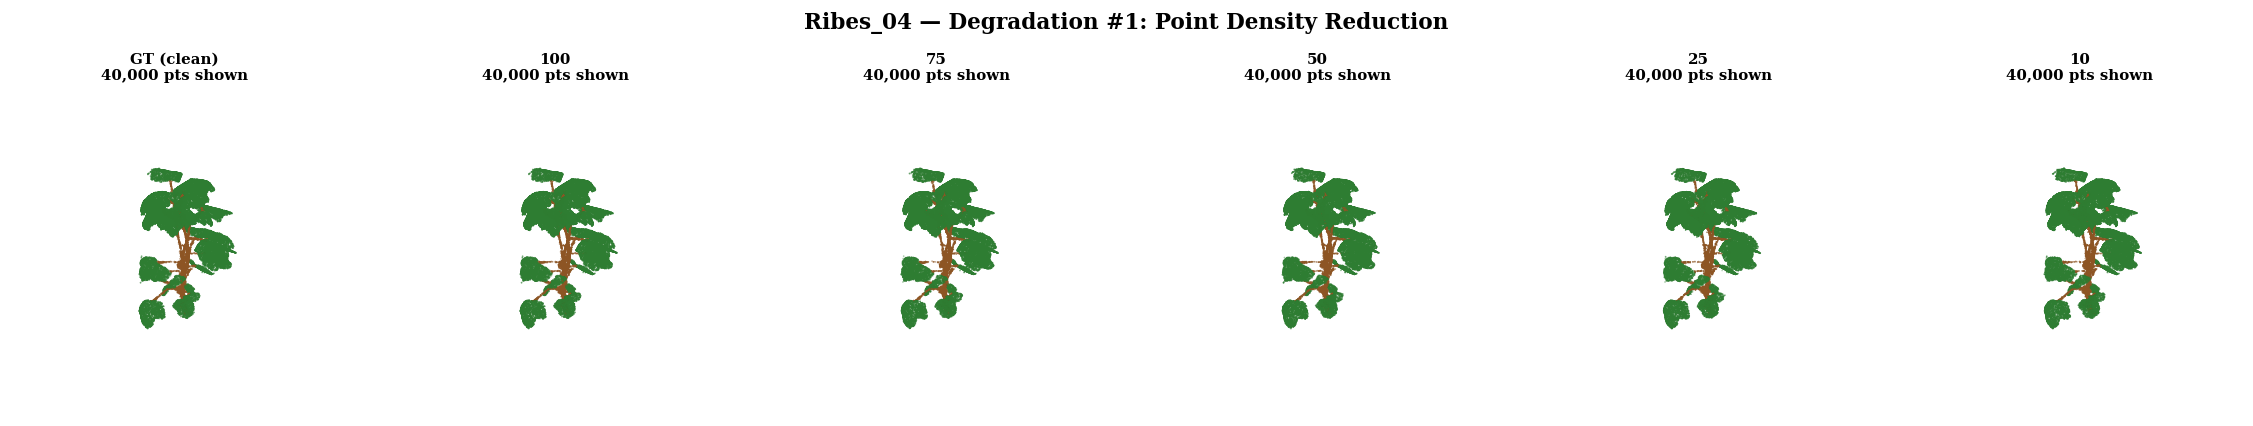

Saved comparison figure: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews/01_density_reduction_comparison.png


In [7]:
plot_category_preview(
    "density", [100, 75, 50, 25, 10],
    "01_density_reduction_comparison",
    f"{PLANT_NAME} — Degradation #1: Point Density Reduction",
)


## 6. Degradation #2 — Coordinate noise

Isotropic Gaussian jitter on `XYZ`. σ is expressed as a **percentage of the
plant's characteristic size** (bounding-box diagonal `CHAR_SIZE`), which is far
more defensible in a paper than an arbitrary absolute σ, since it scales with
plant size. Labels are untouched (same points, same order — only coordinates move).


In [8]:
NOISE_LEVELS = {"low": 0.001, "medium": 0.005, "high": 0.01}  # 0.1% / 0.5% / 1% of CHAR_SIZE

def add_coordinate_noise(sigma_fraction, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    sigma = sigma_fraction * CHAR_SIZE
    noise = rng.normal(0, sigma, size=points.shape)
    return points + noise, sigma

print("Degradation #2 — coordinate noise")
for level, frac in NOISE_LEVELS.items():
    noisy_points, sigma_val = add_coordinate_noise(frac, seed=RANDOM_SEED)
    process_and_save(
        "coordinate_noise", level,
        noisy_points, rgb_colors, semantic_labels, instance_labels, confidence_scores,
        param_desc=f"sigma={frac*100:.2f}% of CHAR_SIZE ({sigma_val:.5f} units)",
    )


Degradation #2 — coordinate noise
  [coordinate_noise/low] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/coordinate_noise/low
  [coordinate_noise/medium] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/coordinate_noise/medium
  [coordinate_noise/high] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/coordinate_noise/high


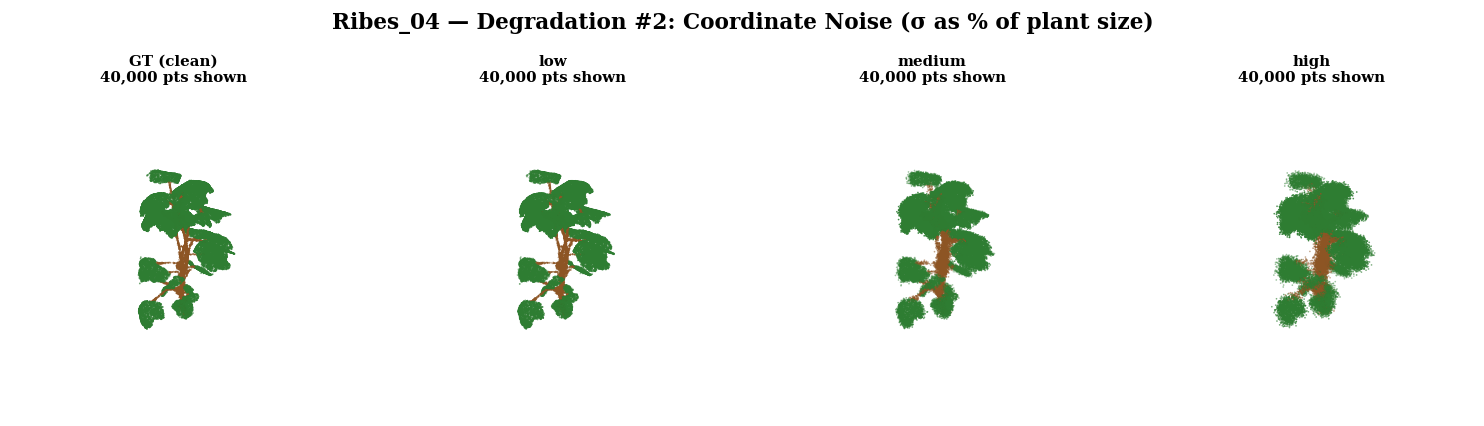

Saved comparison figure: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews/02_coordinate_noise_comparison.png


In [9]:
plot_category_preview(
    "coordinate_noise", ["low", "medium", "high"],
    "02_coordinate_noise_comparison",
    f"{PLANT_NAME} — Degradation #2: Coordinate Noise (\u03c3 as % of plant size)",
)


## 7. Degradation #3 — Random *missing* points (spatially clumped)

Different from #1: instead of i.i.d. random removal, points are removed in
small **spatial clumps** (via KD-tree neighborhood queries around random seed
points) until the target removal fraction is reached — much closer to how a
real reconstruction loses coverage (small patches drop out) than pure i.i.d. subsampling.


In [10]:
from scipy.spatial import cKDTree

CLUMP_RADIUS_FRAC = 0.03   # each clump has radius = 3% of CHAR_SIZE
MISSING_LEVELS = {10: 0.10, 30: 0.30, 50: 0.50}

def spatially_correlated_removal(remove_fraction, clump_radius_frac=CLUMP_RADIUS_FRAC, seed=RANDOM_SEED, safety_iters=200_000):
    n = points.shape[0]
    target_remove = int(round(n * remove_fraction))
    radius = clump_radius_frac * CHAR_SIZE
    tree = cKDTree(points)
    removed = np.zeros(n, dtype=bool)
    rng = np.random.default_rng(seed)
    it = 0
    while removed.sum() < target_remove and it < safety_iters:
        candidates = np.where(~removed)[0]
        if len(candidates) == 0:
            break
        seed_idx = rng.choice(candidates)
        nbrs = tree.query_ball_point(points[seed_idx], radius)
        removed[nbrs] = True
        it += 1
    # trim overshoot so the removal fraction matches the target closely
    removed_idx = np.where(removed)[0]
    excess = removed_idx.size - target_remove
    if excess > 0:
        restore = rng.choice(removed_idx, size=excess, replace=False)
        removed[restore] = False
    return ~removed, radius

print("Degradation #3 — spatially clumped missing points")
for level, frac in MISSING_LEVELS.items():
    keep_mask, radius_used = spatially_correlated_removal(frac, seed=RANDOM_SEED + level)
    idx = np.where(keep_mask)[0]
    process_and_save(
        "missing_points", level,
        points[idx], (rgb_colors[idx] if rgb_colors is not None else None),
        semantic_labels[idx], instance_labels[idx], confidence_scores[idx],
        param_desc=f"target_removed={frac*100:.0f}% (clumped, clump_radius={CLUMP_RADIUS_FRAC*100:.0f}% of CHAR_SIZE = {radius_used:.4f})",
    )


Degradation #3 — spatially clumped missing points
  [missing_points/10] 1,071,329 pts ( 90.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/missing_points/10
  [missing_points/30] 833,256 pts ( 70.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/missing_points/30
  [missing_points/50] 595,183 pts ( 50.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/missing_points/50


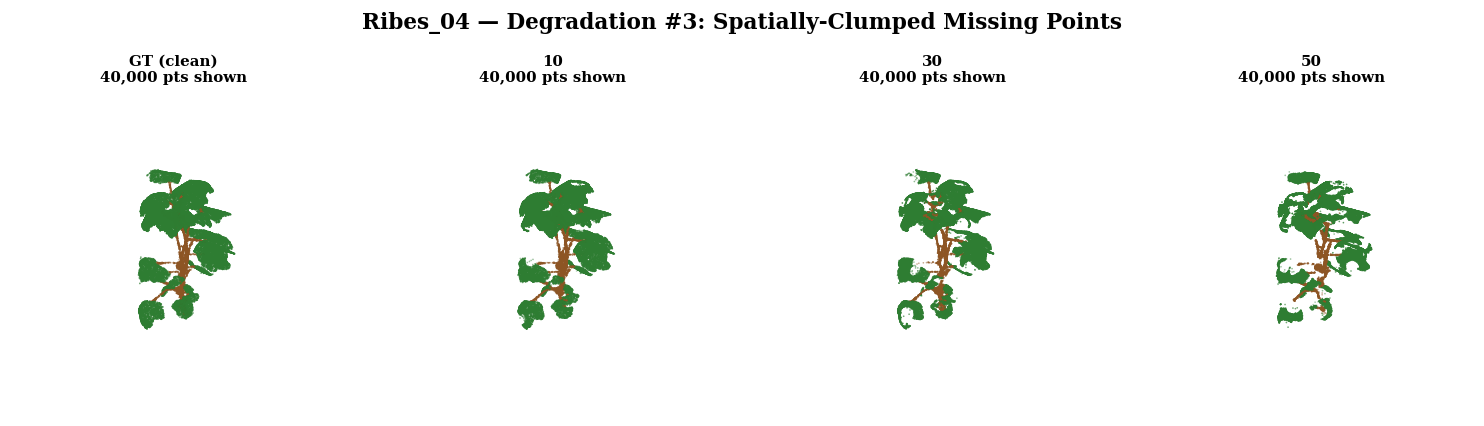

Saved comparison figure: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews/03_missing_points_comparison.png


In [11]:
plot_category_preview(
    "missing_points", [10, 30, 50],
    "03_missing_points_comparison",
    f"{PLANT_NAME} — Degradation #3: Spatially-Clumped Missing Points",
)


## 8. Degradation #4 — Missing *regions* (occlusion cutouts)

Removes **entire spherical regions**, not scattered points — simulating
occlusion, self-occlusion, or a reconstruction failure that wipes out a whole
leaf portion. Sphere centers are drawn from existing GT points (so cutouts
always intersect real plant geometry) with a radius scaled to `CHAR_SIZE`.


In [12]:
REGION_LEVELS = {
    "small":  (1, 0.10),   # 1 region,  radius = 10% of CHAR_SIZE
    "medium": (2, 0.15),   # 2 regions, radius = 15% of CHAR_SIZE
    "large":  (3, 0.20),   # 3 regions, radius = 20% of CHAR_SIZE
}

def remove_spherical_regions(n_regions, radius_frac, seed=RANDOM_SEED):
    radius = radius_frac * CHAR_SIZE
    tree = cKDTree(points)
    removed = np.zeros(points.shape[0], dtype=bool)
    rng = np.random.default_rng(seed)
    centers = []
    for _ in range(n_regions):
        candidates = np.where(~removed)[0]
        if len(candidates) == 0:
            break
        c_idx = rng.choice(candidates)
        center = points[c_idx]
        centers.append(center)
        nbrs = tree.query_ball_point(center, radius)
        removed[nbrs] = True
    return ~removed, centers, radius

print("Degradation #4 — missing regions (occlusion)")
for level, (n_reg, rad_frac) in REGION_LEVELS.items():
    keep_mask, centers, radius_used = remove_spherical_regions(n_reg, rad_frac, seed=RANDOM_SEED + n_reg)
    idx = np.where(keep_mask)[0]
    process_and_save(
        "missing_regions", level,
        points[idx], (rgb_colors[idx] if rgb_colors is not None else None),
        semantic_labels[idx], instance_labels[idx], confidence_scores[idx],
        param_desc=f"{n_reg} spherical region(s), radius={rad_frac*100:.0f}% of CHAR_SIZE ({radius_used:.4f} units)",
    )


Degradation #4 — missing regions (occlusion)
  [missing_regions/small] 1,093,706 pts ( 91.9% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/missing_regions/small
  [missing_regions/medium] 908,392 pts ( 76.3% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/missing_regions/medium
  [missing_regions/large] 509,112 pts ( 42.8% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/missing_regions/large


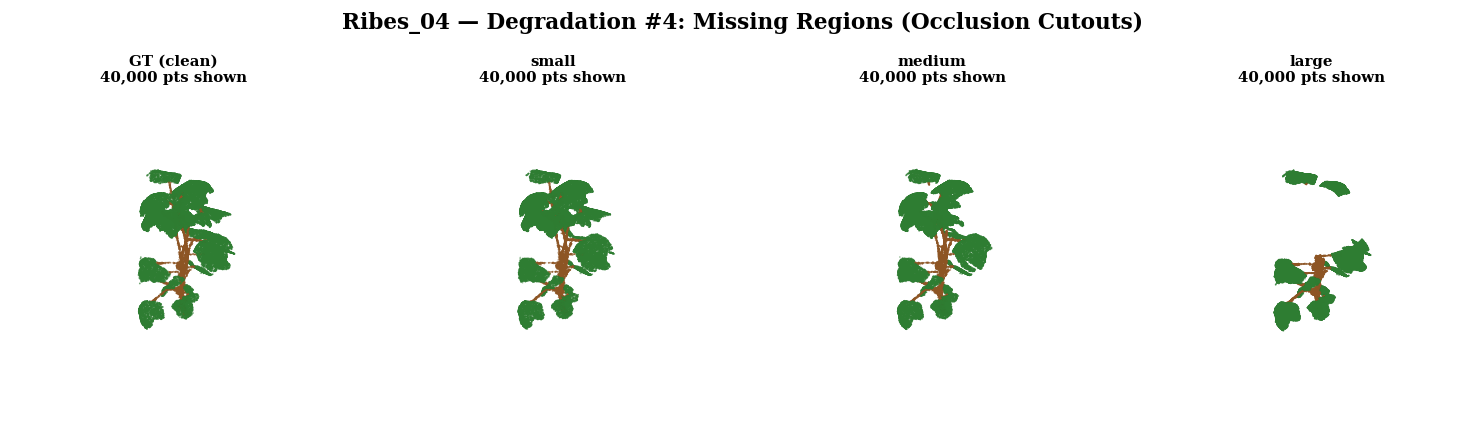

Saved comparison figure: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews/04_missing_regions_comparison.png


In [13]:
plot_category_preview(
    "missing_regions", ["small", "medium", "large"],
    "04_missing_regions_comparison",
    f"{PLANT_NAME} — Degradation #4: Missing Regions (Occlusion Cutouts)",
)


## 9. Degradation #5 — Uneven density (per-organ / per-instance)

Instead of a single global keep-fraction, every **instance** (e.g. each
individual leaf, using your `InstanceLabels`) gets its own random keep-fraction
drawn from a level-dependent range — so leaf A can stay dense while leaf B goes
sparse, exactly like uneven real-world reconstruction coverage.


In [14]:
UNEVEN_LEVELS = {
    "mild":     (0.70, 1.00),
    "moderate": (0.40, 0.90),
    "severe":   (0.10, 0.80),
}

def uneven_density(frac_range, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    keep_mask = np.zeros(points.shape[0], dtype=bool)
    per_instance_fraction = {}
    for inst in unique_instance:
        frac = rng.uniform(*frac_range)
        per_instance_fraction[int(inst)] = round(float(frac), 3)
        inst_idx = np.where(instance_labels == inst)[0]
        k = max(1, int(round(len(inst_idx) * frac)))
        chosen = rng.choice(inst_idx, size=k, replace=False)
        keep_mask[chosen] = True
    return keep_mask, per_instance_fraction

print("Degradation #5 — uneven density (per-instance)")
uneven_fraction_log = {}
for level, frac_range in UNEVEN_LEVELS.items():
    keep_mask, per_inst = uneven_density(frac_range, seed=RANDOM_SEED + hash(level) % 1000)
    uneven_fraction_log[level] = per_inst
    idx = np.where(keep_mask)[0]
    process_and_save(
        "uneven_density", level,
        points[idx], (rgb_colors[idx] if rgb_colors is not None else None),
        semantic_labels[idx], instance_labels[idx], confidence_scores[idx],
        param_desc=f"per-instance keep_fraction ~ U{frac_range}",
    )


Degradation #5 — uneven density (per-instance)
  [uneven_density/mild] 993,001 pts ( 83.4% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/uneven_density/mild
  [uneven_density/moderate] 742,811 pts ( 62.4% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/uneven_density/moderate
  [uneven_density/severe] 576,557 pts ( 48.4% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/uneven_density/severe


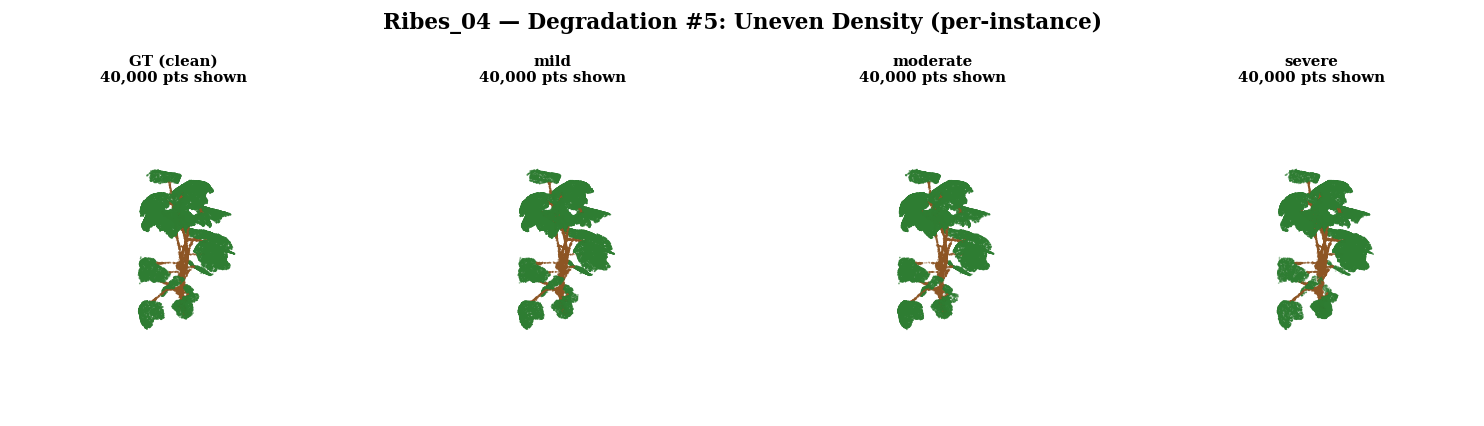

Saved comparison figure: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews/05_uneven_density_comparison.png


In [15]:
plot_category_preview(
    "uneven_density", ["mild", "moderate", "severe"],
    "05_uneven_density_comparison",
    f"{PLANT_NAME} — Degradation #5: Uneven Density (per-instance)",
)


## 10. Degradation #6 — RGB / illumination

Only applied if the GT `.ply` carries color. Geometry and labels are
**untouched** — only `RGB` changes, which is why this is placed last: your
main robustness axis for a reconstruction-quality study is geometric (#1-#5),
and illumination is a secondary nuisance factor for RGB-dependent models.


Degradation #6 — RGB / illumination
  [illumination/dark] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/illumination/dark
  [illumination/bright] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/illumination/bright
  [illumination/low_contrast] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/illumination/low_contrast
  [illumination/color_shift] 1,190,366 pts (100.0% of GT) -> /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/illumination/color_shift


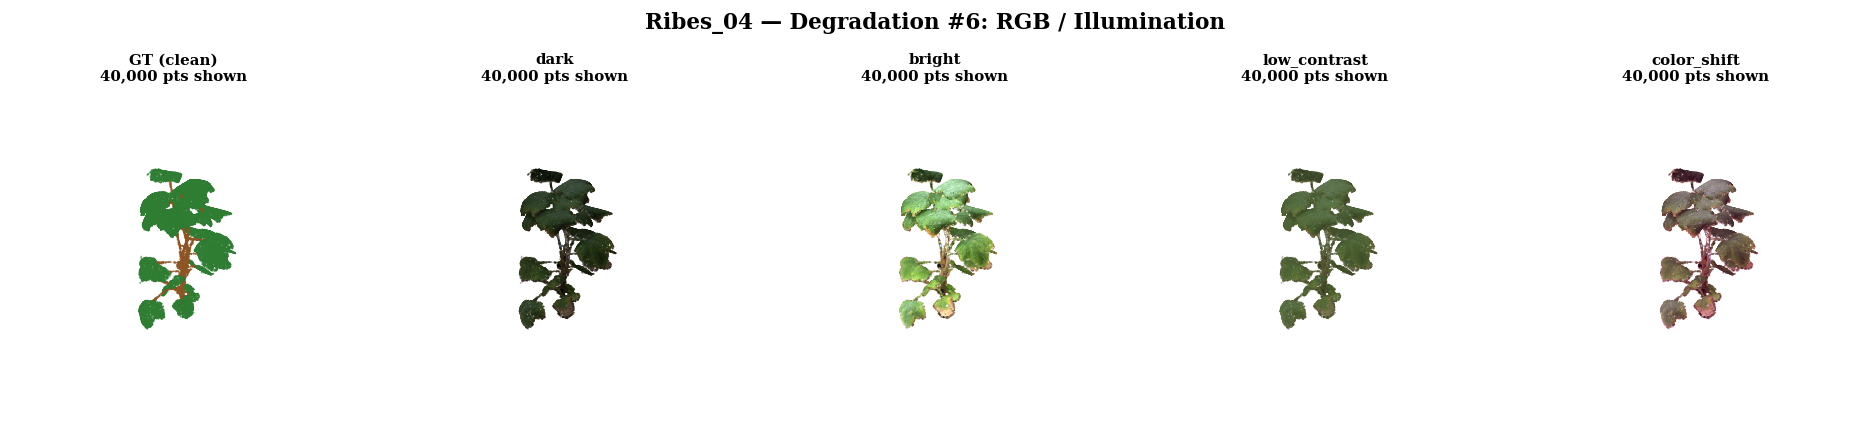

Saved comparison figure: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/figures/degradation_previews/06_illumination_comparison.png


In [16]:
def adjust_brightness(colors, factor):
    return np.clip(colors * factor, 0, 1)

def adjust_contrast(colors, factor):
    mean = colors.mean(axis=0, keepdims=True)
    return np.clip(mean + (colors - mean) * factor, 0, 1)

def apply_color_shift(colors, shift):
    return np.clip(colors + np.array(shift), 0, 1)

ILLUM_VARIANTS = {
    "dark":         ("brightness", 0.5),
    "bright":       ("brightness", 1.5),
    "low_contrast": ("contrast", 0.4),
    "color_shift":  ("shift", [0.12, -0.05, 0.08]),
}

print("Degradation #6 — RGB / illumination")
if rgb_colors is not None:
    for level, (kind, param) in ILLUM_VARIANTS.items():
        if kind == "brightness":
            new_colors, desc = adjust_brightness(rgb_colors, param), f"brightness factor={param}"
        elif kind == "contrast":
            new_colors, desc = adjust_contrast(rgb_colors, param), f"contrast factor={param}"
        else:
            new_colors, desc = apply_color_shift(rgb_colors, param), f"RGB shift={param}"
        process_and_save(
            "illumination", level,
            points, new_colors, semantic_labels, instance_labels, confidence_scores,
            param_desc=desc, preview_mode="rgb",
        )
    plot_category_preview(
        "illumination", ["dark", "bright", "low_contrast", "color_shift"],
        "06_illumination_comparison",
        f"{PLANT_NAME} — Degradation #6: RGB / Illumination",
    )
else:
    print("GT point cloud has no RGB colors — skipping illumination degradation.")


## 11. Manifest — every generated variant, with exact parameters and point counts

In [17]:
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(MANIFEST_PATH, index=False)
print(f"Manifest saved to: {MANIFEST_PATH}\n")
manifest_df


Manifest saved to: /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/manifest.csv



,category,level,params,n_points,pct_of_clean,output_dir
0,density,100,keep_fraction=1.0,1190366,100.00,/content/drive/MyDrive/segmentation_jetcobot_i...
1,density,75,keep_fraction=0.75,892774,75.00,/content/drive/MyDrive/segmentation_jetcobot_i...
2,density,50,keep_fraction=0.5,595183,50.00,/content/drive/MyDrive/segmentation_jetcobot_i...
3,density,25,keep_fraction=0.25,297592,25.00,/content/drive/MyDrive/segmentation_jetcobot_i...
4,density,10,keep_fraction=0.1,119037,10.00,/content/drive/MyDrive/segmentation_jetcobot_i...
5,coordinate_noise,low,sigma=0.10% of CHAR_SIZE (0.04650 units),1190366,100.00,/content/drive/MyDrive/segmentation_jetcobot_i...
6,coordinate_noise,medium,sigma=0.50% of CHAR_SIZE (0.23250 units),1190366,100.00,/content/drive/MyDrive/segmentation_jetcobot_i...
7,coordinate_noise,high,sigma=1.00% of CHAR_SIZE (0.46501 units),1190366,100.00,/content/drive/MyDrive/segmentation_jetcobot_i...
8,missing_points,10,"target_removed=10% (clumped, clump_radius=3% o...",1071329,90.00,/content/drive/MyDrive/segmentation_jetcobot_i...
9,missing_points,30,"target_removed=30% (clumped, clump_radius=3% o...",833256,70.00,/content/drive/MyDrive/segmentation_jetcobot_i...


## ✅ Done — GT preserved, full degradation battery generated

```
noisy_reconstruction/
└── degraded/
    ├── manifest.csv                 (every variant: params + point counts)
    ├── density/{100,75,50,25,10}/
    ├── coordinate_noise/{low,medium,high}/
    ├── missing_points/{10,30,50}/
    ├── missing_regions/{small,medium,large}/
    ├── uneven_density/{mild,moderate,severe}/
    └── illumination/{dark,bright,low_contrast,color_shift}/
```

Each level folder contains `{PLANT_NAME}.ply` + the three matching
`_SemanticLabels.txt` / `_InstanceLabels.txt` / `_Confidence.txt` files —
same format as the GT, so any downstream loader (including the earlier
visualization notebook) works unchanged on these files, just point
`GT_DIR` / `PLY_PATH` at the relevant `degraded/<category>/<level>/` folder.

**Reproducibility note:** every degradation uses a fixed, logged
`numpy.random.default_rng` seed (see `manifest.csv` / cell parameters), so the
exact same noisy point clouds can be regenerated by re-running this notebook —
important for your paper's "experimental setup" section.

**GT integrity:** `gt_reconstruction/` was only ever opened with
`o3d.io.read_point_cloud` / `np.loadtxt` (read-only) — nothing in this
notebook writes to that folder.
